In [1]:
%run constants.py

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3432: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.9/site-packages/numpy/core/_methods.py:190: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [2]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [3]:
from astropy.wcs import WCS
from astropy.coordinates import SpectralCoord
import astropy.units as u

In [4]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/BAND5/load_band5_data.py"

path = band5_data_folder_path

B5 = BuildBandDictionary(
    path,
    StokesI_wcs,
    xmin,
    xmax,
    ymin,
    ymax,
    reference_length_pix,
    reference_length_AU,
    BMAJ_pix,
    BMIN_pix,
    BPA_deg_cartesian,
    max_length_pix,
    reference_fraction,
    POLI_debiased_mJy, # There is no Band 5 debiased yet,
    StokesI_mJy, _, _,
    RA_centre_pix, Dec_centre_pix,
    POLF_debiased
)

stream_vectors_B5 = stream_vectors

B5_header = StokesI_header

band = Band 5
max_str = 'J163135.750-240128.700'
StokesI_wcs CRPIX = [513. 513.]
StokesI_wcs CDELT = [-5.e-06  5.e-06]
Pixel scale = 0.018 arcsec/pixel
Dec_max_pix = 581
 


In [5]:
streamer_file = "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FITS FILES/member.uid___A001_X1354_X270.IRS63_sci.spw33.cube.I.pbcor.fits"


hdu_list = fits.open(streamer_file, memmap=True)
header = hdu_list[0].header
streamer_data = hdu_list[0].data


streamer_StokesI_header, _, streamer_StokesI_Jy, streamer_StokesI_wcs = read_in_file(streamer_file)

# streamer_StokesI_mJy = convert_jy_to_mjy(streamer_StokesI_Jy)
# StokesI_header, _, streamer_Jy, streamer_wcs = read_in_file(streamer_file)

In [6]:
channels = np.arange(476)

freq_hz = streamer_StokesI_header['CRVAL3'] + (channels + 1 - streamer_StokesI_header['CRPIX3']) * streamer_StokesI_header['CDELT3']

freq = freq_hz * u.Hz

velocity = freq.to(
    u.km/u.s,
    equivalencies=u.doppler_radio(streamer_StokesI_header['RESTFRQ'] * u.Hz)
)

print(velocity)

[ 3.98129323e+01  3.96450734e+01  3.94772146e+01  3.93093557e+01
  3.91414968e+01  3.89736379e+01  3.88057791e+01  3.86379202e+01
  3.84700613e+01  3.83022024e+01  3.81343436e+01  3.79664847e+01
  3.77986258e+01  3.76307670e+01  3.74629081e+01  3.72950492e+01
  3.71271903e+01  3.69593315e+01  3.67914726e+01  3.66236137e+01
  3.64557548e+01  3.62878960e+01  3.61200371e+01  3.59521782e+01
  3.57843194e+01  3.56164605e+01  3.54486016e+01  3.52807427e+01
  3.51128839e+01  3.49450250e+01  3.47771661e+01  3.46093072e+01
  3.44414484e+01  3.42735895e+01  3.41057306e+01  3.39378717e+01
  3.37700129e+01  3.36021540e+01  3.34342951e+01  3.32664363e+01
  3.30985774e+01  3.29307185e+01  3.27628596e+01  3.25950008e+01
  3.24271419e+01  3.22592830e+01  3.20914241e+01  3.19235653e+01
  3.17557064e+01  3.15878475e+01  3.14199887e+01  3.12521298e+01
  3.10842709e+01  3.09164120e+01  3.07485532e+01  3.05806943e+01
  3.04128354e+01  3.02449765e+01  3.00771177e+01  2.99092588e+01
  2.97413999e+01  2.95735

In [7]:
velocity[0] - velocity[1]

<Quantity 0.16785887 km / s>

In [8]:
dv = np.abs(np.median(np.diff(velocity.value)))
print(dv)

0.16785887301697855


In [9]:
channels_to_use = np.where(
    (velocity.value >= 2.0) & (velocity.value <= 2.6)
)[0]

print(channels_to_use)

[222 223 224 225]


In [46]:
channels_to_use = np.where(
    (velocity.value >= 0) & (velocity.value <= 5)
)[0]

print(channels_to_use)

[208 209 210 211 212 213 214 215 216 217 218 219 220 221 222 223 224 225
 226 227 228 229 230 231 232 233 234 235 236 237]


In [47]:
moment0 = np.nansum(streamer_data[0, 208:237, :, :], axis=0)# * dv

In [48]:
print(np.nanmin(moment0))
print(np.nanmax(moment0))

print(' ')

print(np.nanmin(moment0)* dv)
print(np.nanmax(moment0)* dv)

-0.15477023
0.19631872
 
-0.02597955559317304
0.032953838388137306


In [49]:
print(np.nanmin(moment0))
print(np.nanmax(moment0))

-0.15477023
0.19631872


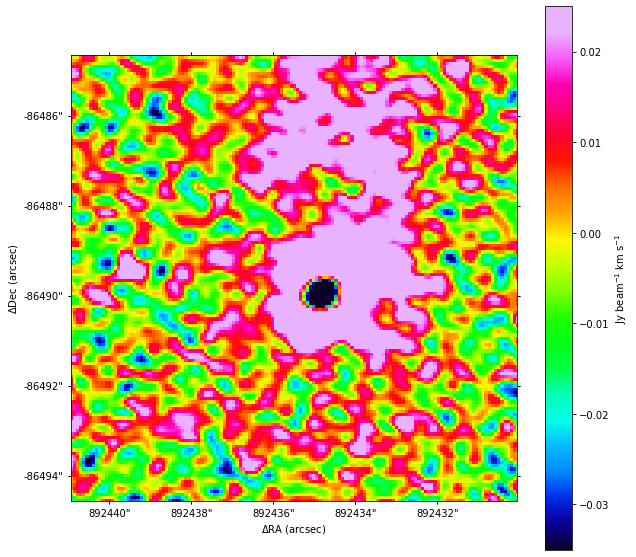

In [50]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection=streamer_StokesI_wcs)

im = ax.imshow(moment0,
          cmap=streamer_cmap,
          origin='lower',
          vmin=-0.035,
          vmax=0.025)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Jy beam$^{-1}$ km s$^{-1}$')

# Convert RA/Dec axes to offsets from the source position
ra = ax.coords[0]
dec = ax.coords[1]

ra.set_axislabel(r'$\Delta$RA (arcsec)')
dec.set_axislabel(r'$\Delta$Dec (arcsec)')

# Set the reference position for the offsets
ra.set_format_unit(u.arcsec)
dec.set_format_unit(u.arcsec)


ax.set_xlim(250, 390)
ax.set_ylim(250, 390)

plt.show()

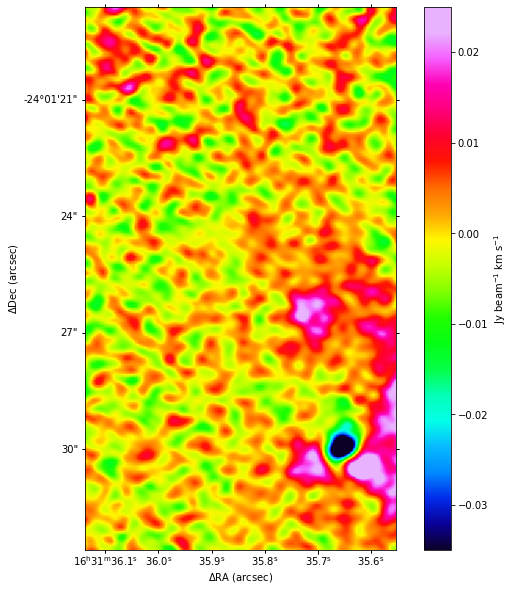

In [17]:
# Pixel scale
pixscale = abs(streamer_StokesI_header['CDELT1']) * 3600  # arcsec/pixel

# Reference pixel (0, 0 offset)
xc = streamer_StokesI_header['CRPIX1'] - 1
yc = streamer_StokesI_header['CRPIX2'] - 1

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection=streamer_StokesI_wcs)

im = ax.imshow(moment0,
               cmap=streamer_cmap,
               origin='lower',
               vmin=-0.035,
               vmax=0.025)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Jy beam$^{-1}$ km s$^{-1}$')

# Desired offset bounds
ra_min, ra_max = -2, 6       # arcsec
dec_min, dec_max = -3, 11    # arcsec

# Convert offsets to pixel positions
# RA is reversed because CDELT1 is negative
x_left = xc - ra_max / pixscale
x_right = xc - ra_min / pixscale

y_bottom = yc + dec_min / pixscale
y_top = yc + dec_max / pixscale

# Zoom to desired bounds
ax.set_xlim(x_left, x_right)
ax.set_ylim(y_bottom, y_top)

# Set offset tick positions
ra_ticks = np.arange(-2, 7, 2)
dec_ticks = np.arange(-2, 12, 2)

ax.set_xticks(xc - ra_ticks / pixscale)
ax.set_xticklabels(ra_ticks)

ax.set_yticks(yc + dec_ticks / pixscale)
ax.set_yticklabels(dec_ticks)

ax.set_xlabel(r'$\Delta$RA (arcsec)')
ax.set_ylabel(r'$\Delta$Dec (arcsec)')

plt.show()

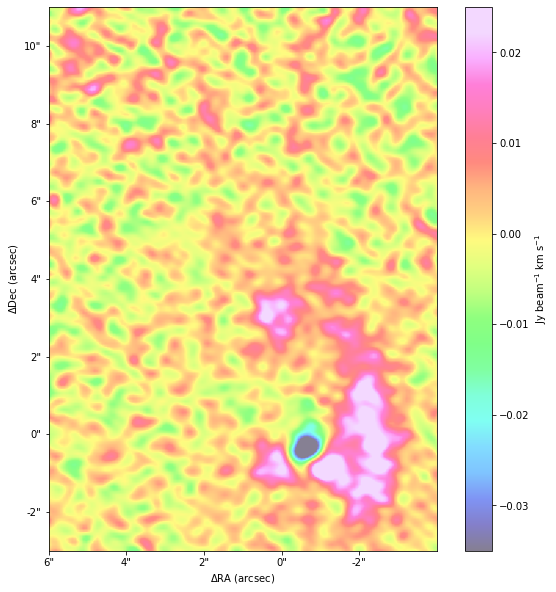

In [40]:
# Pixel scale
pixscale = abs(streamer_StokesI_header['CDELT1']) * 3600  # arcsec/pixel

# Reference pixel
xc = streamer_StokesI_header['CRPIX1'] - 1
yc = streamer_StokesI_header['CRPIX2'] - 1

# Desired offset limits
ra_min, ra_max = -4, 6
dec_min, dec_max = -3, 11

# Convert offsets to pixel coordinates
x_left = xc - ra_max / pixscale
x_right = xc - ra_min / pixscale

y_bottom = yc + dec_min / pixscale
y_top = yc + dec_max / pixscale


fig = plt.figure(figsize=(10, 10))

# Main WCS axes
ax = fig.add_subplot(projection=streamer_StokesI_wcs)

im = ax.imshow(moment0,
               cmap=streamer_cmap,
               alpha = 0.5, 
               origin='lower',
               vmin=-0.035,
               vmax=0.025)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Jy beam$^{-1}$ km s$^{-1}$')

# Set image limits
ax.set_xlim(x_left, x_right)
ax.set_ylim(y_bottom, y_top)

# Hide the original WCS coordinate labels/ticks
ax.coords[0].set_ticks_visible(False)
ax.coords[0].set_ticklabel_visible(False)
ax.coords[1].set_ticks_visible(False)
ax.coords[1].set_ticklabel_visible(False)

# ---------------------------------------------------------
# Add regular Matplotlib axes for ΔRA and ΔDec
# ---------------------------------------------------------

# Position of the image axes in the figure
pos = ax.get_position()

# Create regular axes in exactly the same position
ax2 = fig.add_axes(pos, frameon=False)

# Match the image orientation
# RA increases toward the left
ax2.set_xlim(ra_max, ra_min)
ax2.set_ylim(dec_min, dec_max)

# Ticks
ra_ticks = np.arange(-2, 7, 2)
dec_ticks = np.arange(-2, 12, 2)

ax2.set_xticks(ra_ticks)
ax2.set_yticks(dec_ticks)

# Tick labels as arcseconds
ax2.set_xticklabels([f'{x:g}"' for x in ra_ticks])
ax2.set_yticklabels([f'{y:g}"' for y in dec_ticks])

# Axis labels
ax2.set_xlabel(r'$\Delta$RA (arcsec)')
ax2.set_ylabel(r'$\Delta$Dec (arcsec)')

# Transparent background
ax2.patch.set_alpha(0)

# Tick appearance
ax2.tick_params(axis='both',
                which='both',
                direction='out')



# ---------------------------------------------------------
# Add Band 5 polarization vectors
# ---------------------------------------------------------

# from astropy.wcs.utils import pixel_to_skycoord

# for row in vector_data_actual_cartesian:

#     # Band 5 pixel coordinates
#     start = pixel_to_skycoord(
#         row[0], row[2],
#         B5['StokesI_wcs']
#     )

#     end = pixel_to_skycoord(
#         row[1], row[3],
#         B5['StokesI_wcs']
#     )

#     # Convert to H2CO image pixels
#     x_start, y_start = streamer_StokesI_wcs.world_to_pixel(start)
#     x_end, y_end = streamer_StokesI_wcs.world_to_pixel(end)

#     ax.plot(
#         [x_start, x_end],
#         [y_start, y_end],
#         color='black',
#         lw=2.2
#     )


# # ---------------------------------------------------------
# # Add streamer polarization vectors
# # ---------------------------------------------------------

# for row in stream_vectors:

#     # Streamer vectors are already based on the streamer/Band 5 WCS
#     start = pixel_to_skycoord(
#         row[0], row[2],
#         StokesI_wcs
#     )

#     end = pixel_to_skycoord(
#         row[1], row[3],
#         StokesI_wcs
#     )

#     # Convert to H2CO image pixels
#     x_start, y_start = streamer_StokesI_wcs.world_to_pixel(start)
#     x_end, y_end = streamer_StokesI_wcs.world_to_pixel(end)

#     ax.plot(
#         [x_start, x_end],
#         [y_start, y_end],
#         color='red',
#         lw=2.2
#     )

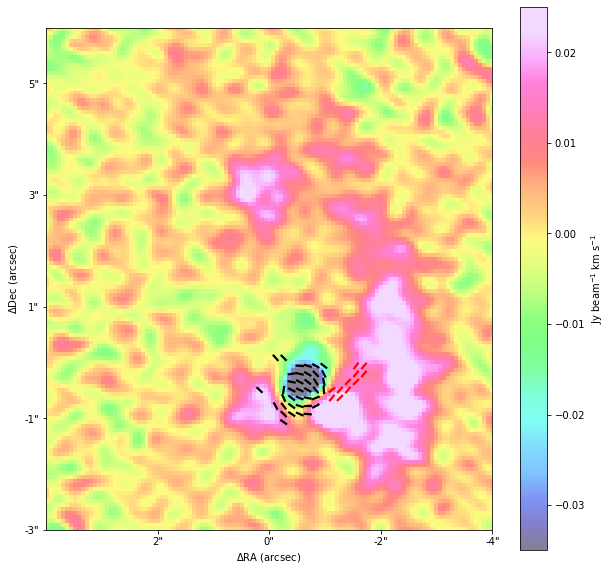

In [45]:
# Pixel scale
pixscale = abs(streamer_StokesI_header['CDELT1']) * 3600  # arcsec/pixel

# Reference pixel
xc = streamer_StokesI_header['CRPIX1'] - 1
yc = streamer_StokesI_header['CRPIX2'] - 1

# Desired offset limits
ra_min, ra_max = -4, 4
dec_min, dec_max = -3, 6

# Convert offsets to pixel coordinates
x_left = xc - ra_max / pixscale
x_right = xc - ra_min / pixscale

y_bottom = yc + dec_min / pixscale
y_top = yc + dec_max / pixscale


fig = plt.figure(figsize=(10, 10))

# Main WCS axes
ax = fig.add_subplot(projection=streamer_StokesI_wcs)

im = ax.imshow(moment0,
               cmap=streamer_cmap,
               alpha = 0.5, 
               origin='lower',
               vmin=-0.035,
               vmax=0.025)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'Jy beam$^{-1}$ km s$^{-1}$')

# Set image limits
ax.set_xlim(x_left, x_right)
ax.set_ylim(y_bottom, y_top)

# Hide the original WCS coordinate labels/ticks
ax.coords[0].set_ticks_visible(False)
ax.coords[0].set_ticklabel_visible(False)
ax.coords[1].set_ticks_visible(False)
ax.coords[1].set_ticklabel_visible(False)

# ---------------------------------------------------------
# Add regular Matplotlib axes for ΔRA and ΔDec
# ---------------------------------------------------------

# Position of the image axes in the figure
pos = ax.get_position()

# Create regular axes in exactly the same position
ax2 = fig.add_axes(pos, frameon=False)

# Match the image orientation
# RA increases toward the left
ax2.set_xlim(ra_max, ra_min)
ax2.set_ylim(dec_min, dec_max)

# Ticks
ra_ticks = np.arange(ra_min, ra_max, 2)
dec_ticks = np.arange(dec_min, dec_max, 2)

ax2.set_xticks(ra_ticks)
ax2.set_yticks(dec_ticks)

# Tick labels as arcseconds
ax2.set_xticklabels([f'{x:g}"' for x in ra_ticks])
ax2.set_yticklabels([f'{y:g}"' for y in dec_ticks])

# Axis labels
ax2.set_xlabel(r'$\Delta$RA (arcsec)')
ax2.set_ylabel(r'$\Delta$Dec (arcsec)')

# Transparent background
ax2.patch.set_alpha(0)

# Tick appearance
ax2.tick_params(axis='both',
                which='both',
                direction='out')



# ---------------------------------------------------------
# Add Band 5 polarization vectors
# ---------------------------------------------------------

from astropy.wcs.utils import pixel_to_skycoord

for row in vector_data_actual_cartesian:

    # Band 5 pixel coordinates
    start = pixel_to_skycoord(
        row[0], row[2],
        B5['StokesI_wcs']
    )

    end = pixel_to_skycoord(
        row[1], row[3],
        B5['StokesI_wcs']
    )

    # Convert to H2CO image pixels
    x_start, y_start = streamer_StokesI_wcs.world_to_pixel(start)
    x_end, y_end = streamer_StokesI_wcs.world_to_pixel(end)

    ax.plot(
        [x_start, x_end],
        [y_start, y_end],
        color='black',
        lw=2.2
    )


# ---------------------------------------------------------
# Add streamer polarization vectors
# ---------------------------------------------------------

for row in stream_vectors:

    # Streamer vectors are already based on the streamer/Band 5 WCS
    start = pixel_to_skycoord(
        row[0], row[2],
        StokesI_wcs
    )

    end = pixel_to_skycoord(
        row[1], row[3],
        StokesI_wcs
    )

    # Convert to H2CO image pixels
    x_start, y_start = streamer_StokesI_wcs.world_to_pixel(start)
    x_end, y_end = streamer_StokesI_wcs.world_to_pixel(end)

    ax.plot(
        [x_start, x_end],
        [y_start, y_end],
        color='red',
        lw=2.2
    )

In [14]:
# def MakeAllBandSingle(b, band_idx, 
#                    fig_x_size = 20, 
#                     fig_y_size = 6.5,
#                     label = 'wavelength',
#                     cmap = soft_colormap_v2,
#                    vector_lw = constants.writeup_grid_lw, # 2.2
#                    axis_num_fs = 16,
#                 axis_label_fs = 22, 
#                    scalebar_fs = 16,
#                    beam_lw = 1.5,
#                    cbar_label_fs = 20,
#                     # This is for the 100 AU and label text
#                     x_pos = 0.06, 
#                     y_pos = 0.85,
#                     AU100_lw = 2.5,
#                     AU100_fs = 20, 
#                     text_fs = 20, 
#                     wspace = 0.12,
#                    for_poster = False,
#                     for_writeup = False, 
#                    ps = 1,
#                    cbar_shrink = 1):
    
    
#     #poster_text1_fs
#     # Change sizes of things if for_poster or not
#     # ---------------------------
#     if for_poster:
#         text_fs = poster_text1_fs * ps
#         AU100_fs = constants.poster_text2_fs * ps
#         spine_width = poster_spine_width 
#         cbar_label_fs = constants.poster_text2_fs * ps
#     # ---------------------------
#     else: 
#         text_fs = text_fs
#         spine_width = 1
#     # ---------------------------
    
    

#     #bands = [B4, B5, B6, B7]
    
    
#     # These things should be the same for all bands
#     StokesI_wcs = b['StokesI_wcs']
    
    
    
#     # Make the figure
#     fig = plt.figure(figsize=(fig_x_size, fig_y_size))
#     axes = []




#     ax = fig.add_subplot(projection=b['StokesI_wcs'])
#     axes.append(ax)


#     ax.coords.frame.set_linewidth(spine_width)


#     # Plot POLI
#     im = ax.imshow(b['POLI_debiased_mJy'], cmap = cmap)

#     # Add a cbar

#     # Make colorbar axis above plot
#     cax = inset_axes(
#         ax,
#         width="100%",
#         height="6%",
#         loc="upper center",
#         bbox_to_anchor=(0, 0.075, 1, 1),
#         bbox_transform=ax.transAxes,
#         borderpad=0
#     )

#     # Add colorbar
#     cbar1 = plt.colorbar(im, cax=cax, orientation="horizontal")

#     # Put ticks on top
#     cbar1.ax.xaxis.set_ticks_position("top")

#     # Format colorbar
#     cbar1.ax.tick_params(
#         labelsize=axis_num_fs,
#         which="major",
#         length=4,
#         direction="in",
#         width=spine_width
#     )

#     cbar1.outline.set_linewidth(spine_width)

#     #cbar1 = plt.colorbar(im, cax = cax, orientation='horizontal', shrink=cbar_shrink, location = 'top')
#     # cbar1.set_label('POLI (mJy beam$^{-1}$)', fontsize=cbar_fs)
# #         cbar1.ax.tick_params(labelsize=axis_num_fs, which='major', length=4, direction="in", width=spine_width,)
# #         cbar1.outline.set_linewidth(spine_width)
#     #cbar1.set_label("Polarized Intensity [mJy beam$^{-1}$]",fontsize=cbar_label_fs)

#     # Add the vectors
#     for j, row in enumerate(b['VectorsActual']):
#         if j == 0:
#             ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw = vector_lw, label = 'Observations')
#         else:
#             ax.plot([row[0], row[1]], [row[2], row[3]], color='black', lw = vector_lw)




#     xmin = b['xmin'] 
#     xmax = b['xmax'] 
#     ymin = b['ymin']
#     ymax = b['ymax'] 

#     print(rf'({xmin}, {xmax}), ({ymin}, {ymax})')

# #         print(f'Band = {i}, and ymax = {ymax}')


#     # Beam location
#     beam_x_pos = xmin - 0.1 * (xmin - xmax)
#     beam_y_pos = ymin - 0.1 * (ymin - ymax)


#     # Add y-axis label to the left
#     if i == 0:
#         ax.set_ylabel("Declination", fontsize=axis_label_fs)

#     # Add an x-axis label to all plots
#     ax.set_xlabel(" ")

#     # Set the x and y lims
#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     # Add the line to each plot
#     # ---------------------------------------------------------
#     # Scalebar line
#     line_x_pos = xmax - 0.04 * (xmax - xmin)
#     line_y_pos = ymin - 0.14 * (ymin - ymax)  -10

#     x0 = line_x_pos - b['reference_length_pix']
#     x1 = line_x_pos

#     ax.plot(
#         [x0, x1],
#         [line_y_pos, line_y_pos],
#         color='black',
#         linewidth=AU100_lw
#     )

#     # ---------------------------------------------------------
#     # Convert midpoint from data coords -> axes coords
#     x_mid_data = (x0 + x1) / 2
#     y_mid_data = line_y_pos

#     display_coords = ax.transData.transform((x_mid_data, y_mid_data))
#     axes_coords = ax.transAxes.inverted().transform(display_coords)

#     x_axes, y_axes = axes_coords

#     # Text directly above middle of line
#     ax.text(
#         x_axes,
#         y_axes + 0.015,
#         f"{b['reference_length_AU']} au",
#         transform=ax.transAxes,
#         fontsize=AU100_fs,
#         ha='center',
#         va='bottom'
#     )

#     add_band_label(ax, band_idx, label, constants, x_pos = x_pos, y_pos = y_pos, 
#                    label_fs = text_fs, va = 'bottom')
#     # ---------------------------------------------------------


#     # Add the beam
#     beam = Ellipse((beam_x_pos, beam_y_pos), width=b['BMAJ_pix'], height=b['BMIN_pix'],  
#                angle=b['BPA_deg_cartesian'], edgecolor='black', facecolor='none', alpha=1, lw=beam_lw)

#     ax.add_patch(beam)

#     # Axis ticks and labels 
#     # ---------------------------------------------------------
#     # Only show y-axis numbers on far left plot
#     ax.coords[1].set_ticklabel_visible(False)
#     ax.coords[1].set_axislabel('')
#     # ---------------------------------------------------------
#     # Tick locations and style
#     ax.coords[0].set_ticks(number=3, direction='in', width=spine_width)
#     ax.coords[1].set_ticks(number=5, direction='in', width=spine_width)

#     # Tick label sizes
#     ax.coords[0].set_ticklabel(size=axis_num_fs)
#     ax.coords[1].set_ticklabel(size=axis_num_fs)
# #         # --------------------------------------------------------


        
    
#     #fig.subplots_adjust(wspace=wspace)
    
#     fig.supxlabel(
#     "Right Ascension",
#     fontsize=axis_label_fs,
#     y=0.04
# )
#     if for_poster:
#         fig.text(
#             0.5,
#             0.03,
#             "Right Ascension",
#             ha='center',
#             fontsize=axis_label_fs
#     )
    
# #     fig.text(
# #         0.025,
# #         0.08,
# #         r'Colour scale: ' '\n' 'Polarized Intensity' '\n' r'(mJy beam$^{-1}$)',
# #         ha='left',
# #         fontsize=15
# #     )

#     fig.text(
#         0.5,          # centered
#         0.995,         # adjust as needed
#         r'Polarized Intensity [mJy beam$^{-1}$]',
#         ha='center',
#         va='top',
#         fontsize=cbar_label_fs
#     )
    
    
#     return fig, axes

NameError: name 'streamer_StokesI_mJy' is not defined

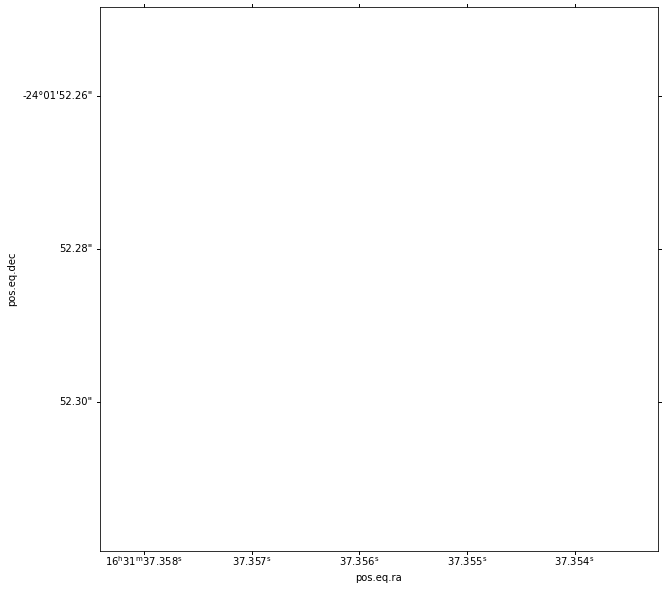

In [15]:
hdul = fits.open(streamer_file, memmap=True)

# Stokes I, first channel

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(projection = streamer_StokesI_wcs)

im = ax.imshow(streamer_StokesI_mJy, cmap = soft_colormap_v2)

cax = inset_axes(
    ax,
    width="100%",
    height="6%",
    loc="upper center",
    bbox_to_anchor=(0, 0.075, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

cbar1 = plt.colorbar(im, cax=cax, orientation="horizontal")

cbar1.ax.xaxis.set_ticks_position("top")

cbar1.ax.tick_params(
    labelsize=axis_num_fs,
    which="major",
    length=4,
    direction="in",
)
    
    
# plt.xlabel("Pixel")
# plt.ylabel("Pixel")
plt.title("IRS 63 H$_2$CO Stokes I")
plt.show()

In [ ]:
hdul = fits.open(streamer_file, memmap=True)

# Stokes I, first channel

fig = plt.figure(figsize=(10, 10))

ax = fig.add_subplot(projection = B5['StokesI_wcs'])

im = ax.imshow(B5['StokesI_mJy'], cmap = soft_colormap_v2)

cax = inset_axes(
    ax,
    width="100%",
    height="6%",
    loc="upper center",
    bbox_to_anchor=(0, 0.075, 1, 1),
    bbox_transform=ax.transAxes,
    borderpad=0
)

cbar1 = plt.colorbar(im, cax=cax, orientation="horizontal")

cbar1.ax.xaxis.set_ticks_position("top")

cbar1.ax.tick_params(
    labelsize=axis_num_fs,
    which="major",
    length=4,
    direction="in",
)
    
    
# plt.xlabel("Pixel")
# plt.ylabel("Pixel")
plt.title("Band 5 Stokes I")
plt.show()

In [ ]:
B5['VectorsActual']

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection=streamer_StokesI_wcs)

ax.imshow(streamer_StokesI_mJy, cmap=soft_colormap_v2, origin='lower')

# Black Band 5 vectors
for row in vector_data_actual_cartesian:

    start = pixel_to_skycoord(row[0], row[2], B5['StokesI_wcs'])
    end   = pixel_to_skycoord(row[1], row[3], B5['StokesI_wcs'])

    x_start, y_start = streamer_StokesI_wcs.world_to_pixel(start)
    x_end, y_end = streamer_StokesI_wcs.world_to_pixel(end)

    ax.plot([x_start, x_end],
            [y_start, y_end],
            color='black', lw=vector_lw)


# Red streamer vectors
for row in stream_vectors:

    start = pixel_to_skycoord(row[0], row[2], StokesI_wcs)
    end   = pixel_to_skycoord(row[1], row[3], StokesI_wcs)

    x_start, y_start = streamer_StokesI_wcs.world_to_pixel(start)
    x_end, y_end = streamer_StokesI_wcs.world_to_pixel(end)

    ax.plot([x_start, x_end],
            [y_start, y_end],
            color='red', lw=vector_lw)

ax.set_xlim(250, 390)
ax.set_ylim(250, 390)

plt.show()

In [ ]:
print("Streamer:")
CDELT1_deg = abs(streamer_StokesI_header['CDELT1'])
pixel_scale_arcsec = CDELT1_deg * 3600
print(pixel_scale_arcsec)

print("Band 5:")
CDELT1_deg = abs(B5_header['CDELT1'])
pixel_scale_arcsec = CDELT1_deg * 3600
print(pixel_scale_arcsec)

In [ ]:
print("Streamer center:")
print(streamer_StokesI_header['CRVAL1'], streamer_StokesI_header['CRVAL2'])

print("Band 5 center:")
print(B5_header['CRVAL1'], B5_header['CRVAL2'])